In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
)

In [2]:
URL = (
    "https://raw.githubusercontent.com/IBM/telco-customer-churn-on-icp4d"
    "/master/data/Telco-Customer-Churn.csv"
)

df = pd.read_csv(URL)

print(f"Rows: {df.shape[0]}  |  Columns: {df.shape[1]}")
print("\nFirst look:")
print(df.head(3).to_string())

Rows: 7043  |  Columns: 21

First look:
   customerID  gender  SeniorCitizen Partner Dependents  tenure PhoneService     MultipleLines InternetService OnlineSecurity OnlineBackup DeviceProtection TechSupport StreamingTV StreamingMovies        Contract PaperlessBilling     PaymentMethod  MonthlyCharges TotalCharges Churn
0  7590-VHVEG  Female              0     Yes         No       1           No  No phone service             DSL             No          Yes               No          No          No              No  Month-to-month              Yes  Electronic check           29.85        29.85    No
1  5575-GNVDE    Male              0      No         No      34          Yes                No             DSL            Yes           No              Yes          No          No              No        One year               No      Mailed check           56.95       1889.5    No
2  3668-QPYBK    Male              0      No         No       2          Yes                No             DSL    

In [3]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df.dropna(subset=["TotalCharges"], inplace=True)
df.drop("customerID", axis=1, inplace=True)

print(f"Clean dataset: {df.shape[0]} rows, {df.shape[1]} columns")
print(f"Missing values: {df.isnull().sum().sum()}")

Clean dataset: 7032 rows, 20 columns
Missing values: 0


In [4]:
yes_no_cols = [
    "Partner", "Dependents", "PhoneService", "PaperlessBilling", "Churn",
    "MultipleLines", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "StreamingTV", "StreamingMovies",
]
for col in yes_no_cols:
    df[col] = df[col].map({
        "Yes": 1, "No": 0,
        "No phone service": 0, "No internet service": 0,
    })

df["gender"] = df["gender"].map({"Male": 1, "Female": 0})

df = pd.get_dummies(
    df,
    columns=["InternetService", "Contract", "PaymentMethod"],
    drop_first=True,
)

print("Encoded dataset shape:", df.shape)
print("Columns:", list(df.columns))

Encoded dataset shape: (7032, 24)
Columns: ['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'PaperlessBilling', 'MonthlyCharges', 'TotalCharges', 'Churn', 'InternetService_Fiber optic', 'InternetService_No', 'Contract_One year', 'Contract_Two year', 'PaymentMethod_Credit card (automatic)', 'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check']



Class distribution:
  Stayed  (0) :  5163  (73.4%)
  Churned (1) :  1869  (26.6%)


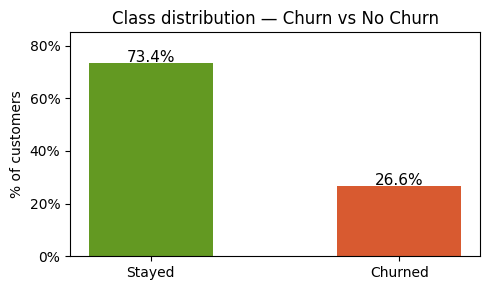

Saved to churn_imbalance.png


In [16]:
counts = df["Churn"].value_counts()
pcts   = df["Churn"].value_counts(normalize=True) * 100

print("\nClass distribution:")
print(f"  Stayed  (0) : {counts[0]:>5}  ({pcts[0]:.1f}%)")
print(f"  Churned (1) : {counts[1]:>5}  ({pcts[1]:.1f}%)")

fig, ax = plt.subplots(figsize=(5, 3))
ax.bar(["Stayed", "Churned"], [pcts[0], pcts[1]],
       color=["#639922", "#D85A30"], width=0.5)
ax.yaxis.set_major_formatter(mtick.PercentFormatter())
ax.set_ylabel("% of customers")
ax.set_title("Class distribution — Churn vs No Churn")
for i, v in enumerate([pcts[0], pcts[1]]):
    ax.text(i, v + 0.5, f"{v:.1f}%", ha="center", fontsize=11)
ax.set_ylim(0, 85)
plt.tight_layout()
plt.savefig("churn_imbalance.png", dpi=130)
plt.show()
print("Saved to churn_imbalance.png")

In [15]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTrain : {len(X_train)} rows")
print(f"Test  : {len(X_test)} rows")
print(f"Churn rate in train : {y_train.mean():.1%}")
print(f"Churn rate in test  : {y_test.mean():.1%}  (stratify worked)")


Train : 5625 rows
Test  : 1407 rows
Churn rate in train : 26.6%
Churn rate in test  : 26.6%  (stratify worked)



── Decision Tree Results ──
Accuracy : 77.83%

              precision    recall  f1-score   support

      Stayed       0.85      0.84      0.85      1033
     Churned       0.58      0.60      0.59       374

    accuracy                           0.78      1407
   macro avg       0.72      0.72      0.72      1407
weighted avg       0.78      0.78      0.78      1407



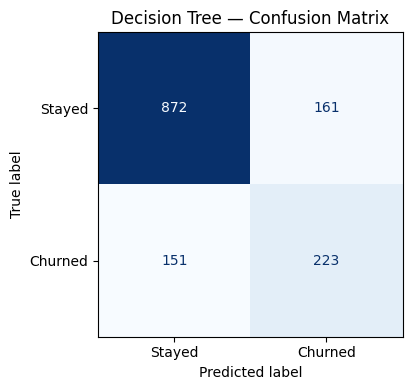

Saved to dt_confusion.png


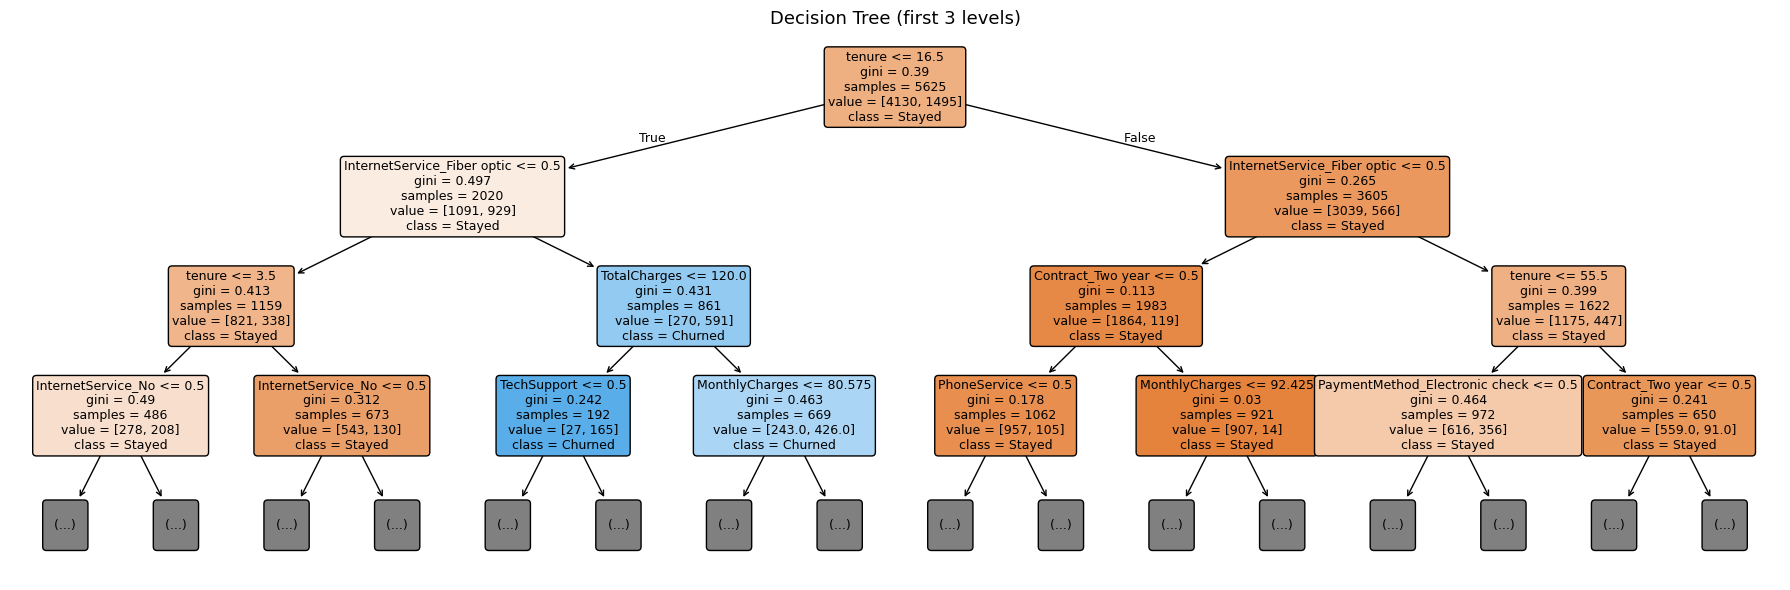

Saved to dt_tree_viz.png


In [17]:
dt = DecisionTreeClassifier(max_depth=5, random_state=42)
dt.fit(X_train, y_train)
dt_preds = dt.predict(X_test)

print("\n── Decision Tree Results ──")
print(f"Accuracy : {accuracy_score(y_test, dt_preds):.2%}")
print()
print(classification_report(y_test, dt_preds, target_names=["Stayed", "Churned"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_preds,
    display_labels=["Stayed", "Churned"],
    colorbar=False, ax=ax,
    cmap="Blues",
)
ax.set_title("Decision Tree — Confusion Matrix")
plt.tight_layout()
plt.savefig("dt_confusion.png", dpi=130)
plt.show()
print("Saved to dt_confusion.png")

fig, ax = plt.subplots(figsize=(18, 6))
plot_tree(
    dt,
    feature_names=X.columns,
    class_names=["Stayed", "Churned"],
    max_depth=3,
    filled=True,
    rounded=True,
    fontsize=9,
    ax=ax,
)
ax.set_title("Decision Tree (first 3 levels)", fontsize=13)
plt.tight_layout()
plt.savefig("dt_tree_viz.png", dpi=130)
plt.show()
print("Saved to dt_tree_viz.png")


── Random Forest Results ──
Accuracy : 79.46%

              precision    recall  f1-score   support

      Stayed       0.83      0.90      0.87      1033
     Churned       0.65      0.50      0.56       374

    accuracy                           0.79      1407
   macro avg       0.74      0.70      0.71      1407
weighted avg       0.78      0.79      0.79      1407



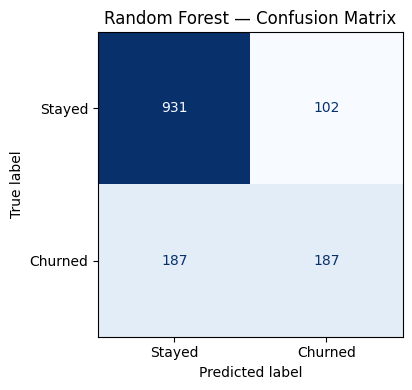

Saved to rf_confusion.png


In [13]:
rf = RandomForestClassifier(n_estimators=100, max_depth=10, random_state=42)
rf.fit(X_train, y_train)
rf_preds = rf.predict(X_test)

print("\n── Random Forest Results ──")
print(f"Accuracy : {accuracy_score(y_test, rf_preds):.2%}")
print()
print(classification_report(y_test, rf_preds, target_names=["Stayed", "Churned"]))

fig, ax = plt.subplots(figsize=(5, 4))
ConfusionMatrixDisplay.from_predictions(
    y_test, rf_preds,
    display_labels=["Stayed", "Churned"],
    colorbar=False, ax=ax,
    cmap="Blues",
)
ax.set_title("Random Forest — Confusion Matrix")
plt.tight_layout()
plt.savefig("rf_confusion.png", dpi=130)
plt.show()
print("Saved to rf_confusion.png")

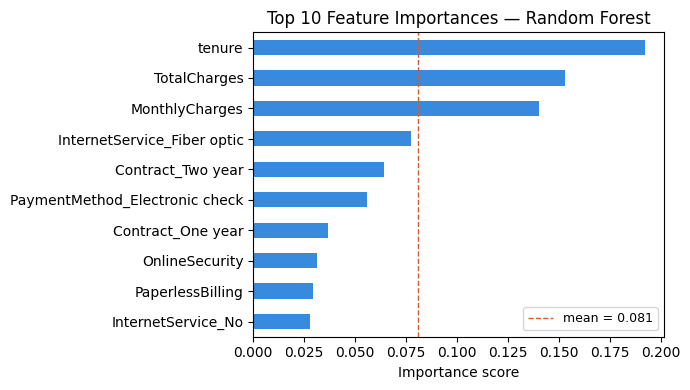

Saved to feature_importance.png

Top 10 features:
  tenure                                   0.1918
  TotalCharges                             0.1528
  MonthlyCharges                           0.1402
  InternetService_Fiber optic              0.0771
  Contract_Two year                        0.0643
  PaymentMethod_Electronic check           0.0560
  Contract_One year                        0.0368
  OnlineSecurity                           0.0310
  PaperlessBilling                         0.0295
  InternetService_No                       0.0280


In [12]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top10 = importances.sort_values(ascending=False).head(10)

fig, ax = plt.subplots(figsize=(7, 4))
top10.sort_values().plot(kind="barh", color="#378ADD", ax=ax)
ax.set_title("Top 10 Feature Importances — Random Forest")
ax.set_xlabel("Importance score")
ax.axvline(top10.mean(), color="#D85A30", linestyle="--", linewidth=1,
           label=f"mean = {top10.mean():.3f}")
ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig("feature_importance.png", dpi=130)
plt.show()
print("Saved to feature_importance.png")

print("\nTop 10 features:")
for feat, score in top10.items():
    print(f"  {feat:<40} {score:.4f}")

In [11]:
def get_metrics(y_true, y_pred):
    return {
        "Accuracy":  accuracy_score(y_true, y_pred),
        "Precision": precision_score(y_true, y_pred),
        "Recall":    recall_score(y_true, y_pred),
        "F1 Score":  f1_score(y_true, y_pred),
    }

dt_metrics = get_metrics(y_test, dt_preds)
rf_metrics = get_metrics(y_test, rf_preds)

print(f"  {'Metric':<14}  {'Decision Tree':>14}  {'Random Forest':>14}")
for metric in dt_metrics:
    dt_val = dt_metrics[metric]
    rf_val = rf_metrics[metric]
    winner = "- RF wins" if rf_val > dt_val else ""
    print(f"  {metric:<14}  {dt_val:>13.2%}  {rf_val:>13.2%}  {winner}")

  Metric           Decision Tree   Random Forest
  Accuracy               77.83%         79.46%  - RF wins
  Precision              58.07%         64.71%  - RF wins
  Recall                 59.63%         50.00%  
  F1 Score               58.84%         56.41%  
